In [15]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

DATA_PATH = "data/ai_psychosis.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)
df.head()

,id,type,subreddit,category,author,created_utc,created_dt,month,score,upvote_ratio,...,is_gallery,is_crosspost,domain,url,link_flair_text,removed_by_category,distinguished,stickied,permalink,thread_mentions_ai
0,mpxmep2,comment,artificial,general_ai,FaceDeer,1746057609,2025-05-01 00:00:09,2025-05,-3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,/r/artificial/comments/1kboupa/more_than_half_...,True
1,mpxmf5r,comment,ArtificialSentience,ai_sentience,Electrical_Hat_680,1746057614,2025-05-01 00:00:14,2025-05,2,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,/r/ArtificialSentience/comments/1kaeeju/checku...,True
2,mpxmgx2,comment,ArtificialInteligence,general_ai,YellowSubreddit8,1746057630,2025-05-01 00:00:30,2025-05,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,/r/ArtificialInteligence/comments/1kbmpv3/clau...,True
3,mpxmni2,comment,MyBoyfriendIsAI,ai_partners,SuddenFrosting951,1746057692,2025-05-01 00:01:32,2025-05,3,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,/r/MyBoyfriendIsAI/comments/1kbtk85/how_to_sta...,True
4,mpxmso1,comment,singularity,general_ai,baklava-balaclava,1746057741,2025-05-01 00:02:21,2025-05,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,/r/singularity/comments/1k8nfha/update_top_ope...,False


In [16]:
size_mb = os.path.getsize(DATA_PATH) / (1024 ** 2)
n_rows = len(df)

print(f"total size: {size_mb:.2f} MB")
print(f"total rows: {n_rows}")


total size: 1238.04 MB
total rows: 2409486


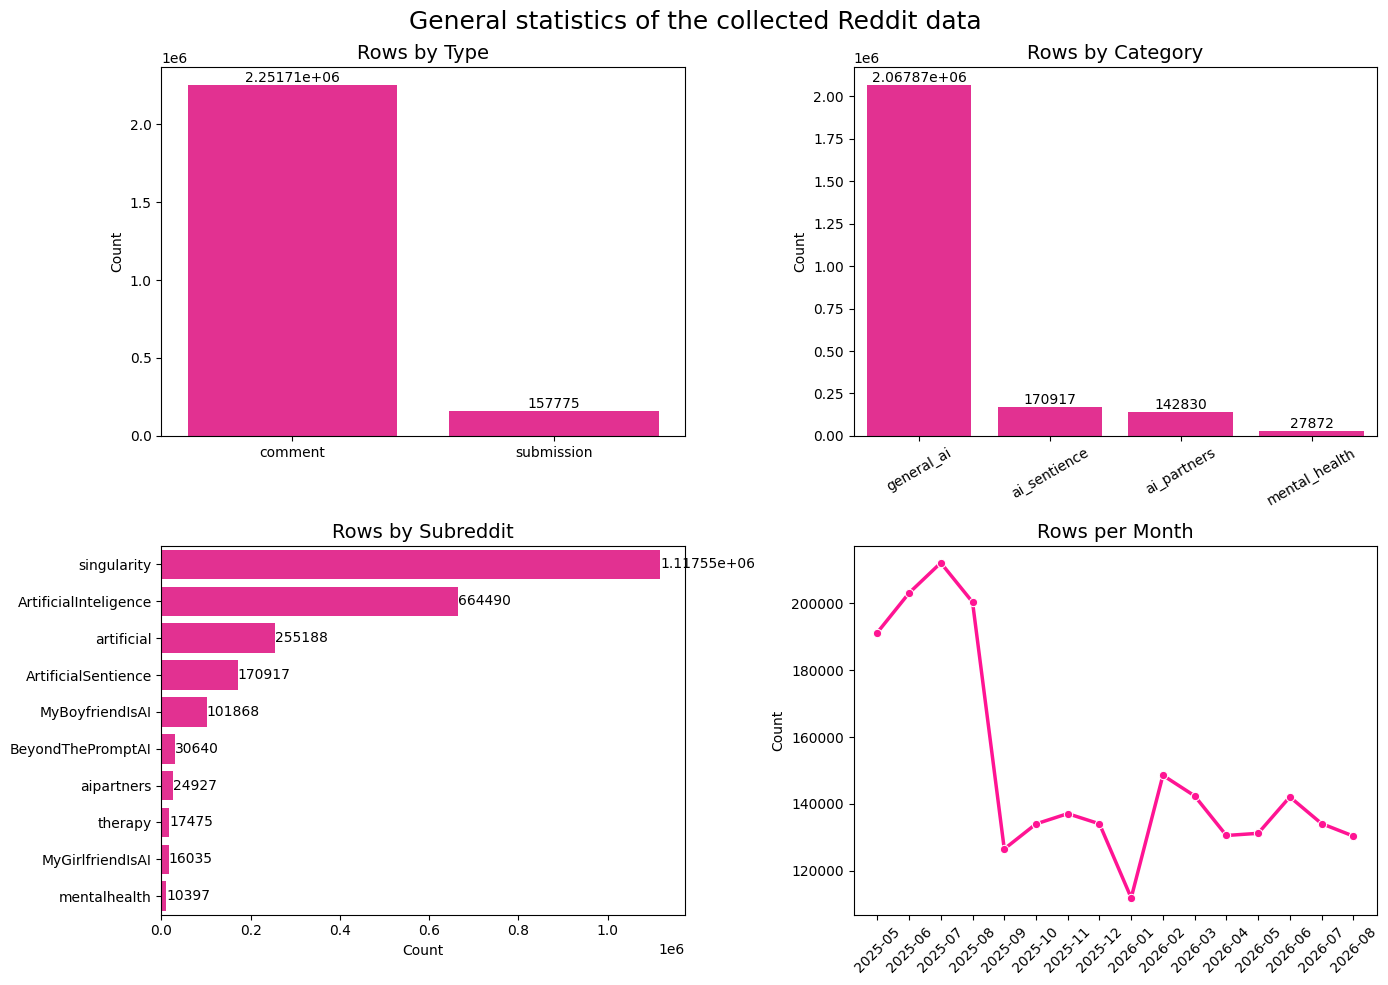

type
comment       2251711
submission     157775
Name: count, dtype: int64
category
general_ai       2067867
ai_sentience      170917
ai_partners       142830
mental_health      27872
Name: count, dtype: int64
subreddit
singularity              1117549
ArtificialInteligence     664490
artificial                255188
ArtificialSentience       170917
MyBoyfriendIsAI           101868
BeyondThePromptAI          30640
aipartners                 24927
therapy                    17475
MyGirlfriendIsAI           16035
mentalhealth               10397
Name: count, dtype: int64
month
2025-05    191287
2025-06    203114
2025-07    212146
2025-08    200384
2025-09    126486
2025-10    133991
2025-11    137071
2025-12    134019
2026-01    111852
2026-02    148534
2026-03    142379
2026-04    130529
2026-05    131176
2026-06    142073
2026-07    134086
2026-08    130359
Name: count, dtype: int64


In [22]:
type_counts = df["type"].value_counts()
category_counts = df["category"].value_counts()
subreddit_counts = df["subreddit"].value_counts()
month_counts = df["month"].value_counts().sort_index()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(x=type_counts.index, y=type_counts.values, color="#ff1493", ax=axes[0, 0])
axes[0, 0].set_title("Rows by Type", fontsize=14)
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_xlabel("")
for c in axes[0, 0].containers:
    axes[0, 0].bar_label(c, color="black")

sns.barplot(x=category_counts.index, y=category_counts.values, color="#ff1493", ax=axes[0, 1])
axes[0, 1].set_title("Rows by Category", fontsize=14)
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_xlabel("")
axes[0, 1].tick_params(axis="x", rotation=30)
for c in axes[0, 1].containers:
    axes[0, 1].bar_label(c, color="black")

sns.barplot(x=subreddit_counts.values, y=subreddit_counts.index, color="#ff1493", ax=axes[1, 0])
axes[1, 0].set_title("Rows by Subreddit", fontsize=14)
axes[1, 0].set_xlabel("Count")
axes[1, 0].set_ylabel("")
for c in axes[1, 0].containers:
    axes[1, 0].bar_label(c, color="black")

sns.lineplot(x=month_counts.index, y=month_counts.values, color="#ff1493", marker="o", linewidth=2.5, ax=axes[1, 1])
axes[1, 1].set_title("Rows per Month", fontsize=14)
axes[1, 1].set_ylabel("Count")
axes[1, 1].set_xlabel("")
axes[1, 1].tick_params(axis="x", rotation=45)


fig.suptitle("General statistics of the collected Reddit data", fontsize=18)
plt.tight_layout()
plt.savefig(
    "reddit_data_statistics.png",
    dpi=300,
    bbox_inches='tight',
    format='png'
)
plt.show()

print(type_counts)
print(category_counts)
print(subreddit_counts)
print(month_counts)

In [18]:
pd.crosstab(df["category"], df["type"])

type,comment,submission
category,,
ai_partners,131224,11606
ai_sentience,160177,10740
general_ai,1934372,133495
mental_health,25938,1934


In [19]:
pd.crosstab(df["subreddit"], df["type"])

type,comment,submission
subreddit,,
ArtificialInteligence,590999,73491
ArtificialSentience,160177,10740
BeyondThePromptAI,27658,2982
MyBoyfriendIsAI,95093,6775
MyGirlfriendIsAI,13910,2125
aipartners,22221,2706
artificial,226518,28670
mentalhealth,9783,614
singularity,1089197,28352


In [20]:
pd.crosstab(
    df["subreddit"].str.replace("ChatGPT", "", regex=False).str.strip(),
    df["type"]
)

type,comment,submission
subreddit,,
ArtificialInteligence,590999,73491
ArtificialSentience,160177,10740
BeyondThePromptAI,27658,2982
MyBoyfriendIsAI,95093,6775
MyGirlfriendIsAI,13910,2125
aipartners,22221,2706
artificial,226518,28670
mentalhealth,9783,614
singularity,1089197,28352
